### ML EN FINANZAS: Proyecto final

# Utilizar datos históricos de pagos de clientes para construir un modelo de predicción de incumplimiento.

Datos usados: https://www.kaggle.com/datasets/daniellopez01/credit-risk

* Paula Pirela
* Jaber Andrés Olarte
* Juan Manuel Peña

### Generalidades

Cargamos librerías para EDA, transformaciones, PCA, clustering, modelos y métricas.

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    confusion_matrix, roc_curve, precision_recall_curve,
    roc_auc_score, average_precision_score, accuracy_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


  Configuraciones de gráficos para validaciones a lo largo del notebook

In [69]:
def quick_check(df, target="default"):
    print("Shape:", df.shape)
    print("Duplicados:", df.duplicated().sum())
    print("\nNulos (top):\n", df.isna().sum().sort_values(ascending=False).head(10))
    print("\nTarget:\n", df[target].value_counts(dropna=False))

def plot_target(y, title="Distribución del target"):
    counts = y.value_counts().sort_index()
    plt.figure()
    plt.bar(["no(0)", "yes(1)"], [counts.get(0,0), counts.get(1,0)])
    plt.title(title)
    plt.ylabel("Conteo")
    plt.show()

def imbalance_report(y):
    counts = y.value_counts().sort_index()
    pct = (counts / counts.sum() * 100).round(2)
    minority = counts.min()
    majority = counts.max()
    ratio = majority / minority if minority > 0 else np.inf

    print("Conteo:\n", counts)
    print("\nPorcentaje:\n", pct.astype(str) + "%")
    print(f"\nImbalance ratio (mayoría/minoría): {ratio:.2f}")
    plot_target(y, title="Distribución del target")
    return ratio

def plot_cum_variance(cum_var, title="Varianza explicada acumulada"):
    plt.figure()
    plt.plot(cum_var, marker="o")
    plt.title(title)
    plt.xlabel("# componentes")
    plt.ylabel("Varianza acumulada")
    plt.ylim(0, 1.01)
    plt.grid(True)
    plt.show()

def plot_silhouette_curve(ks, sils):
    plt.figure()
    plt.plot(list(ks), sils, marker="o")
    plt.title("Silhouette vs k (KMeans sobre PCA)")
    plt.xlabel("k")
    plt.ylabel("silhouette")
    plt.grid(True)
    plt.show()

def plot_2d(Z2, labels=None, title="Proyección 2D"):
    plt.figure()
    if labels is None:
        plt.scatter(Z2[:,0], Z2[:,1], s=10)
    else:
        plt.scatter(Z2[:,0], Z2[:,1], c=labels, s=10)
    plt.title(title)
    plt.xlabel("Comp 1")
    plt.ylabel("Comp 2")
    plt.show()

def plot_roc_pr(y_true, probs, prefix=""):
    fpr, tpr, _ = roc_curve(y_true, probs)
    prec, rec, _ = precision_recall_curve(y_true, probs)

    plt.figure()
    plt.plot(fpr, tpr)
    plt.title(f"{prefix}ROC (AUC={roc_auc_score(y_true, probs):.3f})")
    plt.xlabel("FPR"); plt.ylabel("TPR")
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(rec, prec)
    plt.title(f"{prefix}PR (AP={average_precision_score(y_true, probs):.3f})")
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.grid(True)
    plt.show()

def plot_cm(y_true, probs, thr=0.5, title="Matriz de confusión"):
    pred = (probs >= thr).astype(int)
    cm = confusion_matrix(y_true, pred)
    plt.figure()
    plt.imshow(cm, aspect="auto")
    plt.title(f"{title} (thr={thr})")
    plt.xticks([0,1], ["no","yes"])
    plt.yticks([0,1], ["no","yes"])
    for (i,j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha="center", va="center")
    plt.colorbar()
    plt.xlabel("Predicho"); plt.ylabel("Real")
    plt.show()

def summarize_metrics(name, y_true, probs, thr=0.5):
    pred = (probs >= thr).astype(int)
    return {
        "model": name,
        "ACC": accuracy_score(y_true, pred),
        "ROC_AUC": roc_auc_score(y_true, probs),
        "PR_AUC": average_precision_score(y_true, probs),
    }


Cargamos los datos y realizamos un EDA preliminar

Filas antes: 1000 | después de dropna: 1000 | eliminadas: 0
Conteo:
default
0    700
1    300
Name: count, dtype: int64

Porcentaje:
default
0    70.0%
1    30.0%
Name: count, dtype: object

Imbalance ratio (mayoría/minoría): 2.33


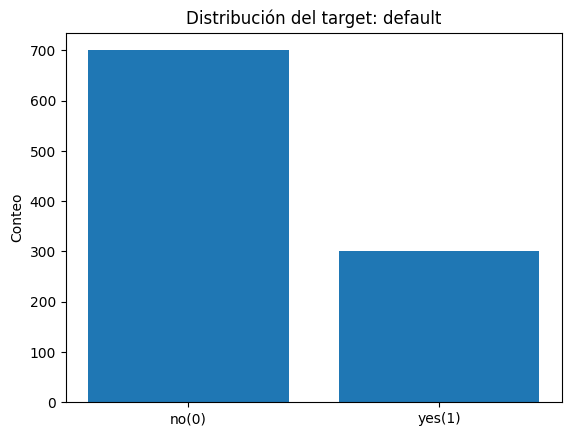

In [70]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/2025-2/04 - ML en finanzas/credit.csv")

before = df.shape[0]
df = df.dropna().copy()
after = df.shape[0]
print(f"Filas antes: {before} | después de dropna: {after} | eliminadas: {before-after}")

y = df["default"].map({"no": 0, "yes": 1}).astype(int)
X = df.drop(columns=["default"])

def imbalance_report(y, name="default"):
    counts = y.value_counts().sort_index()
    pct = (counts / counts.sum() * 100).round(2)

    print("Conteo:")
    print(counts)
    print("\nPorcentaje:")
    print(pct.astype(str) + "%")

    minority = counts.min()
    majority = counts.max()
    ratio = majority / minority if minority > 0 else np.inf
    print(f"\nImbalance ratio (mayoría/minoría): {ratio:.2f}")

    plt.figure()
    plt.bar(["no(0)", "yes(1)"], [counts.get(0,0), counts.get(1,0)])
    plt.title(f"Distribución del target: {name}")
    plt.ylabel("Conteo")
    plt.show()

    return ratio, pct

ratio, pct = imbalance_report(y)


Realizamos un reprocesamiento (One-Hot + Escalado) construyendo una matriz lista para PCA, clustering y modelos.

In [71]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = [c for c in X.columns if c not in num_cols]

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("scaler", StandardScaler())]), num_cols),
        ("cat", ohe, cat_cols),
    ],
    remainder="drop"
)

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)


Numéricas: ['months_loan_duration', 'amount', 'percent_of_income', 'years_at_residence', 'age', 'existing_loans_count', 'dependents']
Categóricas: ['checking_balance', 'credit_history', 'purpose', 'savings_balance', 'employment_duration', 'other_credit', 'housing', 'job', 'phone']


PCA y visualización

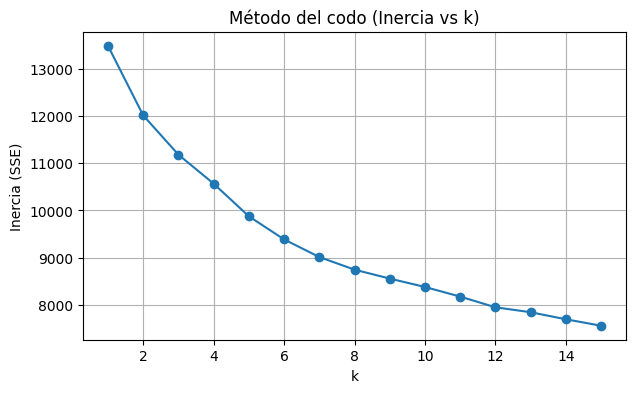

In [72]:
%matplotlib inline

def elbow_plot(Z, k_min=1, k_max=15, random_state=42):
    ks = range(k_min, k_max + 1)
    inertias = []
    for k in ks:
        km = KMeans(n_clusters=k, random_state=random_state, n_init="auto")
        km.fit(Z)
        inertias.append(km.inertia_)

    plt.figure(figsize=(7,4))
    plt.plot(list(ks), inertias, marker="o")
    plt.title("Método del codo (Inercia vs k)")
    plt.xlabel("k")
    plt.ylabel("Inercia (SSE)")
    plt.grid(True)
    plt.show()

elbow_plot(Z_cluster, k_min=1, k_max=15)


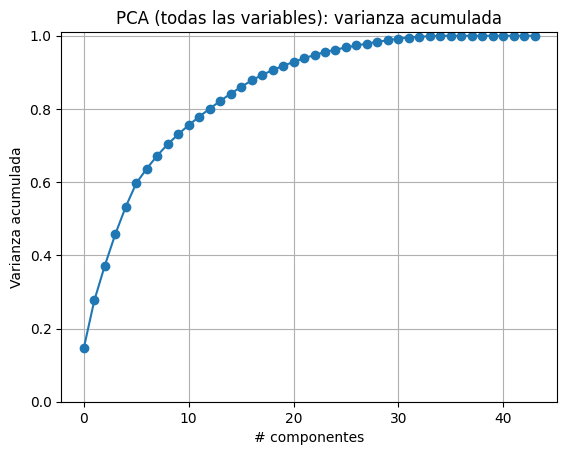

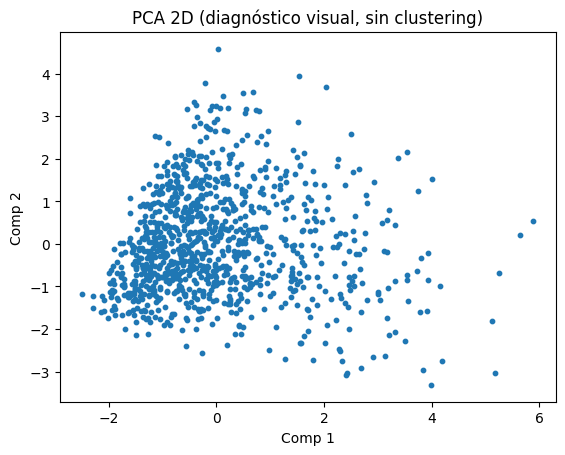

In [73]:
X_mat_full = preprocess.fit_transform(X)
pca_diag = PCA(n_components=None, random_state=42)
Z_diag = pca_diag.fit_transform(X_mat_full)

cum_var = np.cumsum(pca_diag.explained_variance_ratio_)
plot_cum_variance(cum_var, title="PCA (todas las variables): varianza acumulada")

pca2_diag = PCA(n_components=2, random_state=42)
Z2_diag = pca2_diag.fit_transform(X_mat_full)
plot_2d(Z2_diag, title="PCA 2D (diagnóstico visual, sin clustering)")




Cluster usando K-means

PCA clustering -> n_components: 24


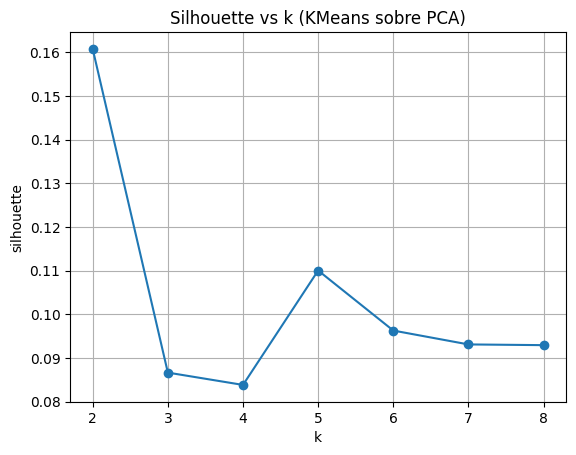

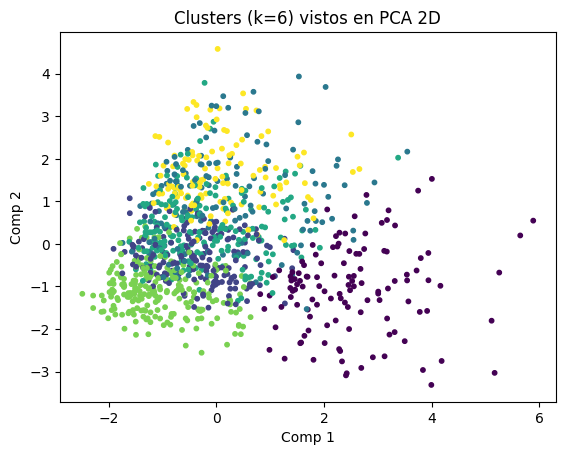

,n,default_rate,avg_amount,avg_duration,avg_age,avg_percent_income
cluster,,,,,,
0,119,0.521008,9060.924370,40.747899,35.495798,2.504202
1,185,0.318919,2508.421622,19.691892,29.848649,2.983784
2,145,0.296552,2953.951724,18.772414,38.744828,2.806897
4,225,0.293333,2158.426667,16.391111,30.031111,3.048889
3,202,0.237624,2644.995050,19.178218,32.183168,3.049505
5,124,0.177419,2263.645161,17.153226,55.838710,3.338710


In [74]:
pca_cluster = PCA(n_components=0.95, random_state=42)
Z_cluster = pca_cluster.fit_transform(X_mat_full)
print("PCA clustering -> n_components:", pca_cluster.n_components_)

ks = range(2, 9)
sils = []
for k in ks:
    labels = KMeans(n_clusters=k, random_state=42, n_init="auto").fit_predict(Z_cluster)
    sils.append(silhouette_score(Z_cluster, labels))
plot_silhouette_curve(ks, sils)

k = 6
kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
cluster_labels = kmeans.fit_predict(Z_cluster)

Z2_for_plot = PCA(n_components=2, random_state=42).fit_transform(X_mat_full)
plot_2d(Z2_for_plot, labels=cluster_labels, title=f"Clusters (k={k}) vistos en PCA 2D")

tmp = df.copy()
tmp["y"] = y
tmp["cluster"] = cluster_labels

cluster_summary = tmp.groupby("cluster").agg(
    n=("y", "size"),
    default_rate=("y", "mean"),
    avg_amount=("amount", "mean"),
    avg_duration=("months_loan_duration", "mean"),
    avg_age=("age", "mean"),
    avg_percent_income=("percent_of_income", "mean"),
).sort_values("default_rate", ascending=False)

display(cluster_summary)



Entrenamiento modelos y comparación

In [75]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Xtr = preprocess.fit_transform(X_train)
Xte = preprocess.transform(X_test)

pca_model = PCA(n_components=0.95, random_state=42)
Xtr_p = pca_model.fit_transform(Xtr)
Xte_p = pca_model.transform(Xte)

print("PCA modelos -> n_components:", pca_model.n_components_)


PCA modelos -> n_components: 24


Aplicamos SMOTE para corregir posible desbalanceo

In [76]:
minority_count = int((y_train == 1).sum())
k_neighbors = max(1, min(5, minority_count - 1))
print("Minoría en train:", minority_count, "| SMOTE k_neighbors:", k_neighbors)

smote = SMOTE(random_state=42, k_neighbors=k_neighbors)

Xtr_p_sm, ytr_sm = smote.fit_resample(Xtr_p, y_train)

print("Antes SMOTE:", Xtr_p.shape, "Después SMOTE:", Xtr_p_sm.shape)
print("Default rate train antes:", y_train.mean().round(3), "después:", ytr_sm.mean().round(3))

Minoría en train: 240 | SMOTE k_neighbors: 5
Antes SMOTE: (800, 24) Después SMOTE: (1120, 24)
Default rate train antes: 0.3 después: 0.5


Entrenamiento y comparación de modelos

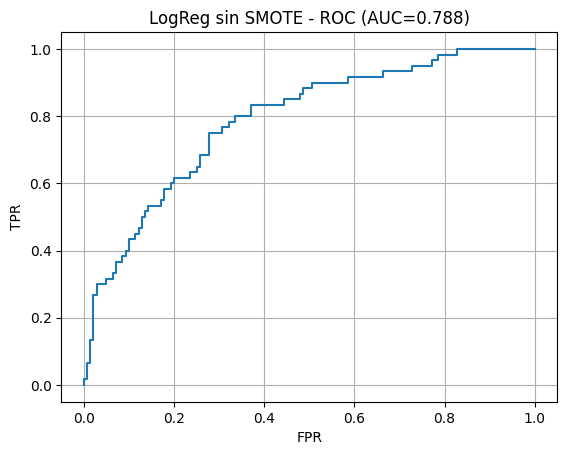

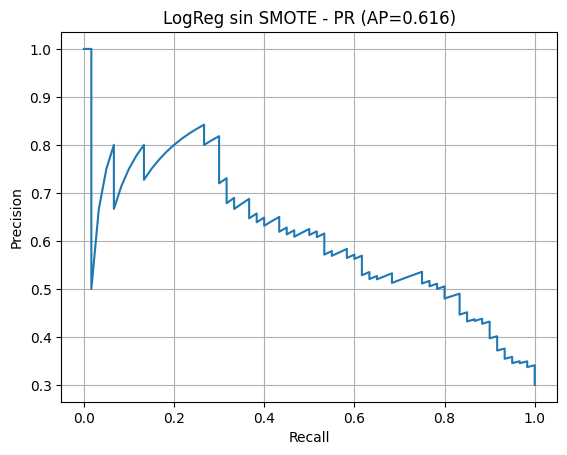

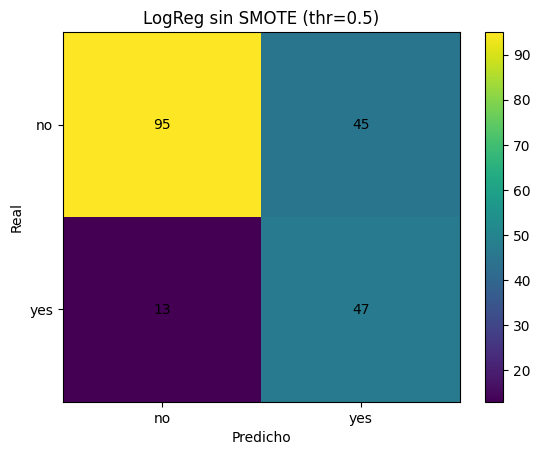

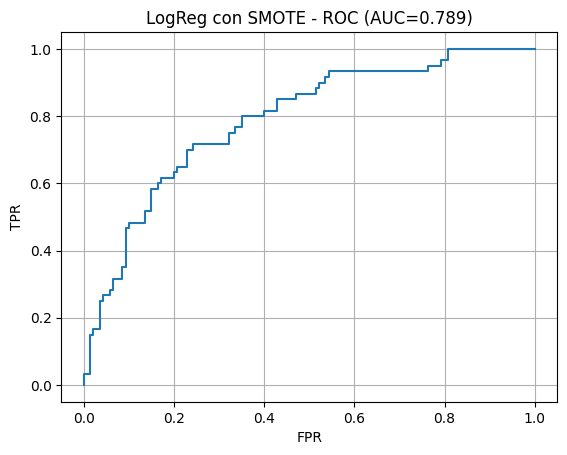

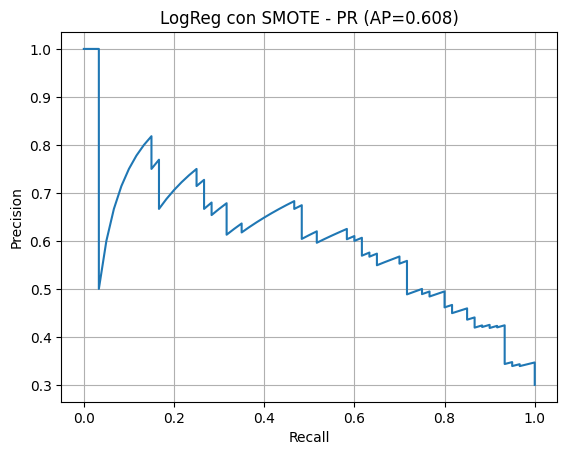

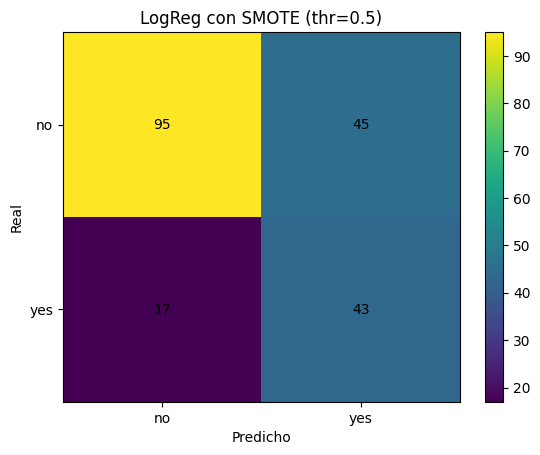

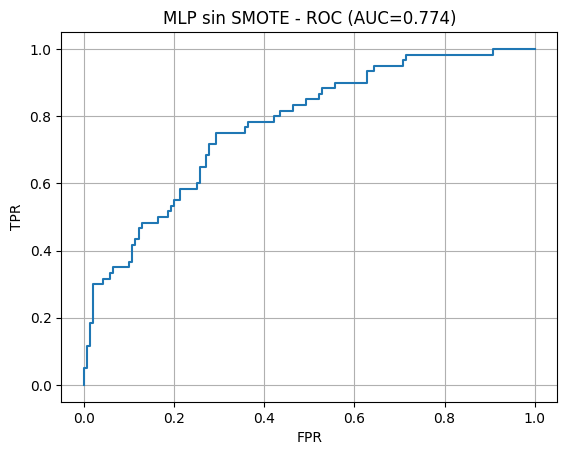

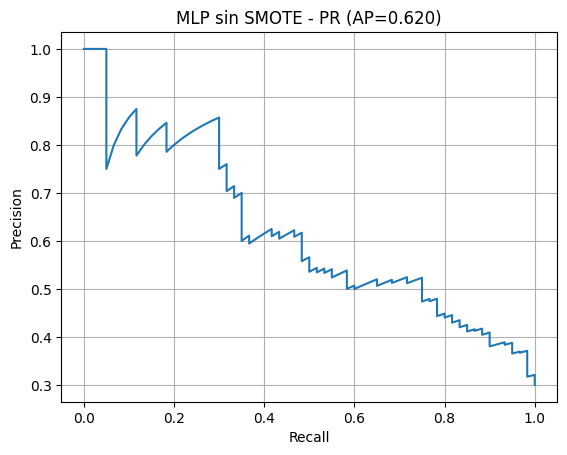

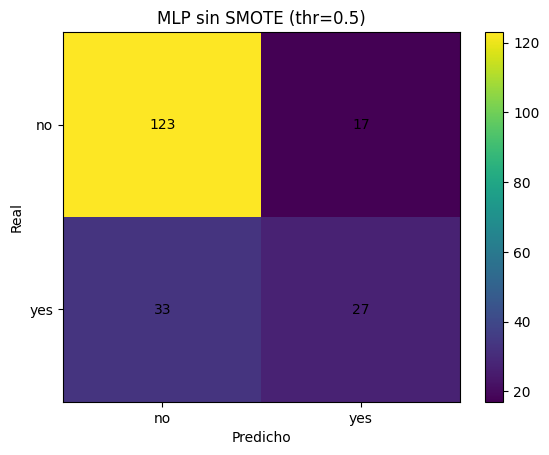

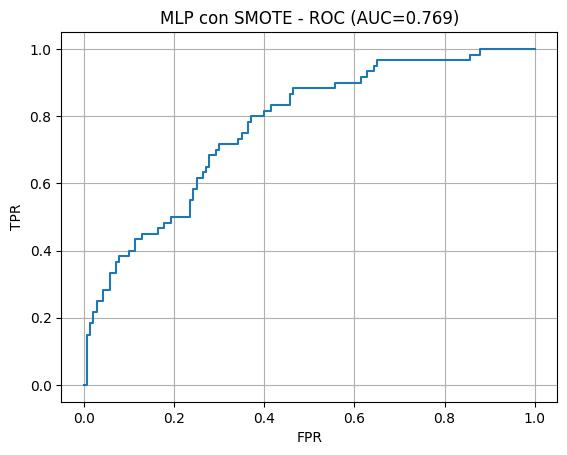

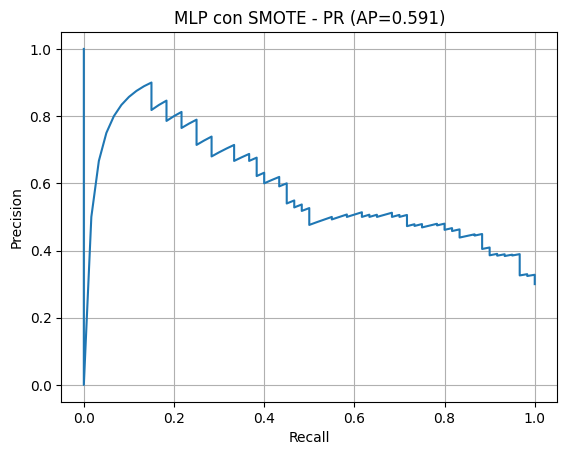

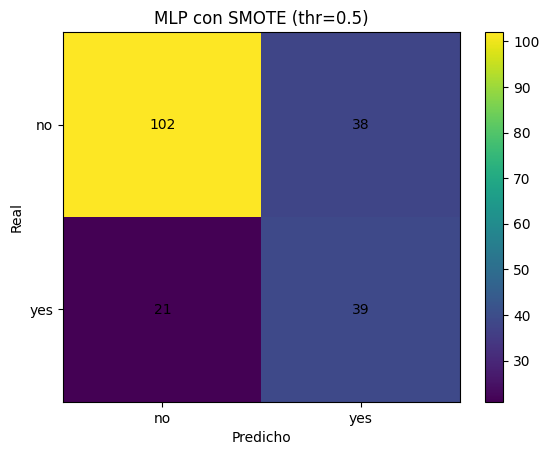

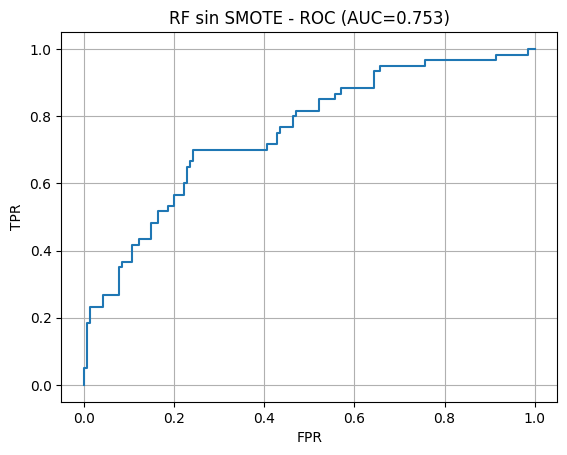

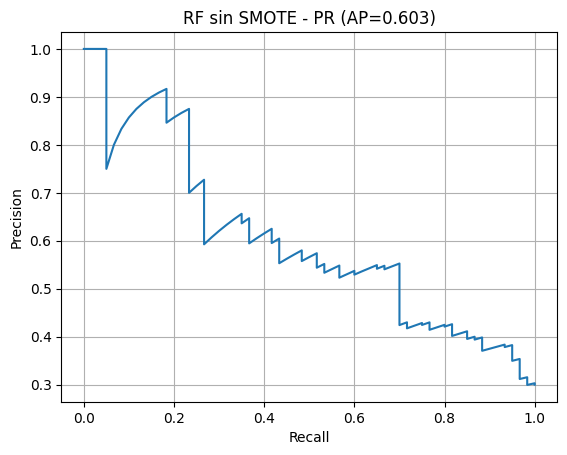

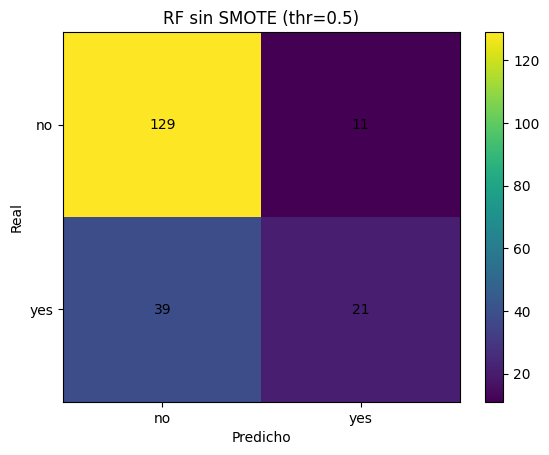

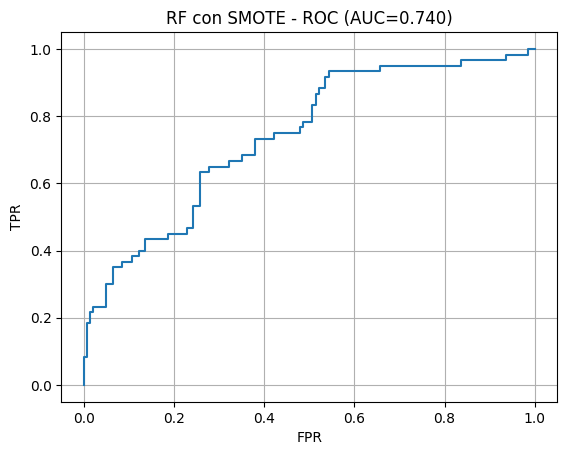

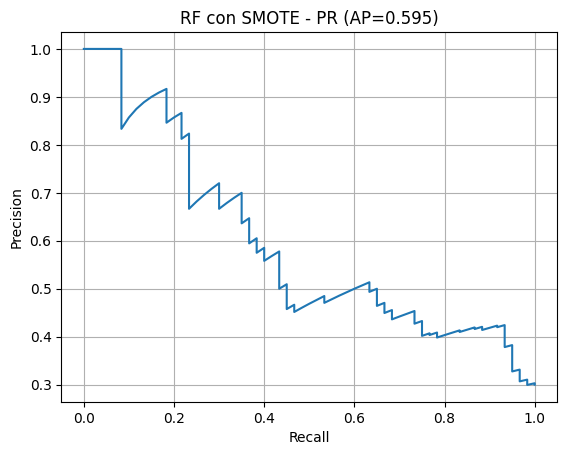

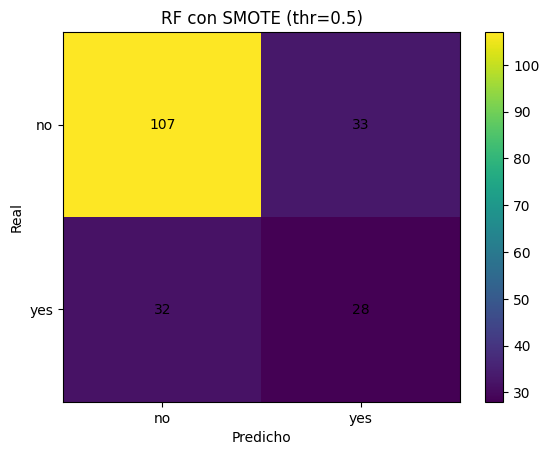

,model,ACC,ROC_AUC,PR_AUC
2,MLP PCA (sin SMOTE),0.750,0.774048,0.619806
0,"LogReg PCA (sin SMOTE, class_weight)",0.710,0.787738,0.616056
1,LogReg PCA (con SMOTE),0.690,0.788571,0.607615
4,RandomForest PCA (sin SMOTE),0.750,0.752738,0.603496
5,RandomForest PCA (con SMOTE),0.675,0.740476,0.594788
3,MLP PCA (con SMOTE),0.705,0.769048,0.590896


In [77]:
results = []

lr = LogisticRegression(max_iter=3000, class_weight="balanced")
lr.fit(Xtr_p, y_train)
p_lr = lr.predict_proba(Xte_p)[:, 1]

results.append(summarize_metrics("LogReg PCA (sin SMOTE, class_weight)", y_test, p_lr))
plot_roc_pr(y_test, p_lr, prefix="LogReg sin SMOTE - ")
plot_cm(y_test, p_lr, thr=0.5, title="LogReg sin SMOTE")

lr_s = LogisticRegression(max_iter=3000)
lr_s.fit(Xtr_p_sm, ytr_sm)
p_lr_s = lr_s.predict_proba(Xte_p)[:, 1]

results.append(summarize_metrics("LogReg PCA (con SMOTE)", y_test, p_lr_s))
plot_roc_pr(y_test, p_lr_s, prefix="LogReg con SMOTE - ")
plot_cm(y_test, p_lr_s, thr=0.5, title="LogReg con SMOTE")

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    batch_size=32,
    learning_rate_init=1e-3,
    max_iter=500,
    random_state=42,
    early_stopping=True
)
mlp.fit(Xtr_p, y_train)
p_mlp = mlp.predict_proba(Xte_p)[:, 1]

results.append(summarize_metrics("MLP PCA (sin SMOTE)", y_test, p_mlp))
plot_roc_pr(y_test, p_mlp, prefix="MLP sin SMOTE - ")
plot_cm(y_test, p_mlp, thr=0.5, title="MLP sin SMOTE")

mlp_s = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    batch_size=32,
    learning_rate_init=1e-3,
    max_iter=500,
    random_state=42,
    early_stopping=True
)
mlp_s.fit(Xtr_p_sm, ytr_sm)
p_mlp_s = mlp_s.predict_proba(Xte_p)[:, 1]

results.append(summarize_metrics("MLP PCA (con SMOTE)", y_test, p_mlp_s))
plot_roc_pr(y_test, p_mlp_s, prefix="MLP con SMOTE - ")
plot_cm(y_test, p_mlp_s, thr=0.5, title="MLP con SMOTE")

rf = RandomForestClassifier(
    n_estimators=600,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample",
    min_samples_leaf=2
)
rf.fit(Xtr_p, y_train)
p_rf = rf.predict_proba(Xte_p)[:, 1]

results.append(summarize_metrics("RandomForest PCA (sin SMOTE)", y_test, p_rf))
plot_roc_pr(y_test, p_rf, prefix="RF sin SMOTE - ")
plot_cm(y_test, p_rf, thr=0.5, title="RF sin SMOTE")

rf_s = RandomForestClassifier(
    n_estimators=600,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample",
    min_samples_leaf=2
)
rf_s.fit(Xtr_p_sm, ytr_sm)
p_rf_s = rf_s.predict_proba(Xte_p)[:, 1]

results.append(summarize_metrics("RandomForest PCA (con SMOTE)", y_test, p_rf_s))
plot_roc_pr(y_test, p_rf_s, prefix="RF con SMOTE - ")
plot_cm(y_test, p_rf_s, thr=0.5, title="RF con SMOTE")

results_df = pd.DataFrame(results).sort_values("PR_AUC", ascending=False)
display(results_df)
